## Create a disease driver heatmap

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# making sure plots & clusters are reproducible
np.random.seed(42)

In [2]:
## path variables
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig3/'

In [3]:
## plotting variables
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load correlation table
correlation_df = pd.read_csv(data_dir + '240830_cell_type_frequency_disease_severity_correlation.csv', sep =',', index_col = 0)

In [5]:
correlation_df.head(5)

,ashcroft_score_spearman_rho_d10,max_body_weight_loss_spearman_rho_d10,ashcroft_score_p_value_d10,ashcroft_score_adjusted_p_value_d10,max_body_weight_loss_p_value_d10,max_body_weight_loss_adjusted_p_value_d10,ashcroft_score_spearman_rho_d21,max_body_weight_loss_spearman_rho_d21,ashcroft_score_p_value_d21,ashcroft_score_adjusted_p_value_d21,max_body_weight_loss_p_value_d21,max_body_weight_loss_adjusted_p_value_d21
AT1,0.477612,0.323208,6.875056e-04,2.315808e-03,1.284107e-02,0.025682,0.329538,0.201191,2.385782e-02,4.362574e-02,0.884490,0.943456
AT2,-0.619906,-0.552230,6.110186e-09,3.910519e-07,1.053483e-05,0.000048,-0.562457,-0.651055,2.228659e-09,2.496258e-08,0.000222,0.001185
AT2 activated,0.188249,0.183826,4.584657e-01,5.536190e-01,8.126755e-01,0.866854,0.092197,-0.039941,2.384291e-01,2.934512e-01,0.499453,0.603113
Krt8+ ADI,0.499049,0.657325,9.216357e-07,9.830781e-06,2.209315e-07,0.000002,0.517119,0.427556,3.854681e-06,2.055830e-05,0.076851,0.136625
Basal,0.149920,0.227104,8.182760e-01,8.182760e-01,3.546257e-01,0.436462,0.359666,0.295983,5.056185e-03,1.198503e-02,0.168677,0.245348


### Prepare data for visualization

In [6]:
## add stars with significance levels to p-value columns
def add_significance_stars(row, p_value_col):
    if row[p_value_col] < 0.001:
        return '***'
    elif row[p_value_col] < 0.01:
        return '**'
    elif row[p_value_col] < 0.05:
        return '*'
    else:
        return ''

In [7]:
## loop through each time point's adj p-values to add significance stars for plotting
for outcome in ['ashcroft_score','max_body_weight_loss']:
    
    for time_point in ['d10', 'd21']:
        
        ## create a new column for stars
        correlation_df[f'stars_{outcome}_{time_point}'] = correlation_df.apply(add_significance_stars, p_value_col=f'{outcome}_adjusted_p_value_{time_point}', axis=1)

In [8]:
correlation_df.head(5)

,ashcroft_score_spearman_rho_d10,max_body_weight_loss_spearman_rho_d10,ashcroft_score_p_value_d10,ashcroft_score_adjusted_p_value_d10,max_body_weight_loss_p_value_d10,max_body_weight_loss_adjusted_p_value_d10,ashcroft_score_spearman_rho_d21,max_body_weight_loss_spearman_rho_d21,ashcroft_score_p_value_d21,ashcroft_score_adjusted_p_value_d21,max_body_weight_loss_p_value_d21,max_body_weight_loss_adjusted_p_value_d21,stars_ashcroft_score_d10,stars_ashcroft_score_d21,stars_max_body_weight_loss_d10,stars_max_body_weight_loss_d21
AT1,0.477612,0.323208,6.875056e-04,2.315808e-03,1.284107e-02,0.025682,0.329538,0.201191,2.385782e-02,4.362574e-02,0.884490,0.943456,**,*,*,
AT2,-0.619906,-0.552230,6.110186e-09,3.910519e-07,1.053483e-05,0.000048,-0.562457,-0.651055,2.228659e-09,2.496258e-08,0.000222,0.001185,***,***,***,**
AT2 activated,0.188249,0.183826,4.584657e-01,5.536190e-01,8.126755e-01,0.866854,0.092197,-0.039941,2.384291e-01,2.934512e-01,0.499453,0.603113,,,,
Krt8+ ADI,0.499049,0.657325,9.216357e-07,9.830781e-06,2.209315e-07,0.000002,0.517119,0.427556,3.854681e-06,2.055830e-05,0.076851,0.136625,***,***,***,
Basal,0.149920,0.227104,8.182760e-01,8.182760e-01,3.546257e-01,0.436462,0.359666,0.295983,5.056185e-03,1.198503e-02,0.168677,0.245348,,*,,


In [9]:
correlation_data = correlation_df[['ashcroft_score_spearman_rho_d10','max_body_weight_loss_spearman_rho_d10','ashcroft_score_spearman_rho_d21','max_body_weight_loss_spearman_rho_d21']]
correlation_annotation = correlation_df[['stars_ashcroft_score_d10','stars_ashcroft_score_d21','stars_max_body_weight_loss_d10','stars_max_body_weight_loss_d21']]

In [10]:
correlation_data.head(2)

,ashcroft_score_spearman_rho_d10,max_body_weight_loss_spearman_rho_d10,ashcroft_score_spearman_rho_d21,max_body_weight_loss_spearman_rho_d21
AT1,0.477612,0.323208,0.329538,0.201191
AT2,-0.619906,-0.552230,-0.562457,-0.651055


In [11]:
correlation_annotation.head(2)

,stars_ashcroft_score_d10,stars_ashcroft_score_d21,stars_max_body_weight_loss_d10,stars_max_body_weight_loss_d21
AT1,**,*,*,
AT2,***,***,***,**


In [12]:
## calculate the linkage  matrix for hierarchical clustering
linkage_matrix = linkage(correlation_data, method='average', metric='euclidean')

/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/seaborn/matrix.py:1214: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


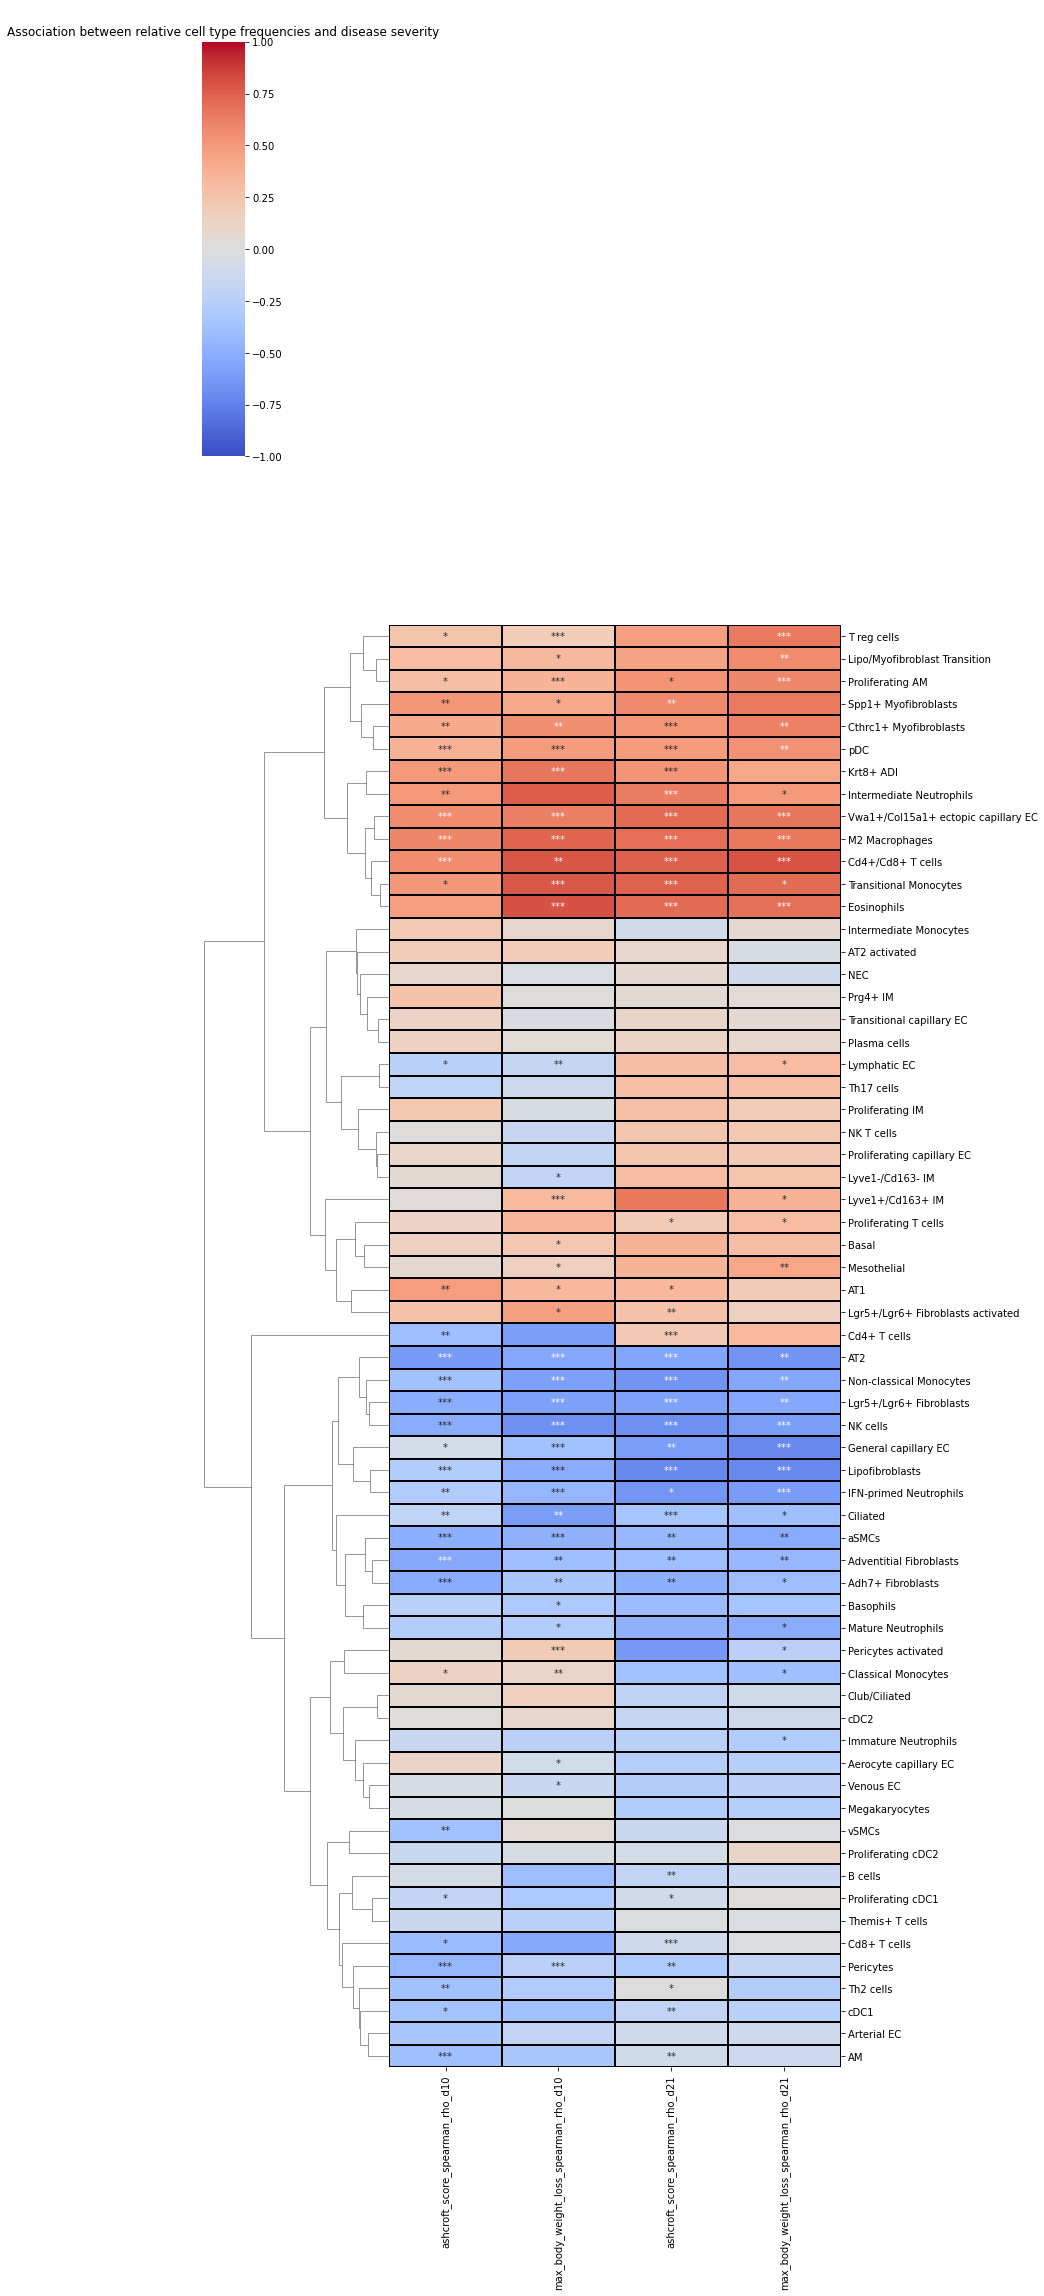

In [13]:
## create a clustermap
g = sb.clustermap(
    correlation_data,
    annot=correlation_annotation,
    fmt='',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    figsize=(12, 32),
    method='average',
    metric='euclidean',
    row_linkage=linkage_matrix,
    col_cluster=False,
    dendrogram_ratio=0.3,
    square=True,
    linewidths=2,  ## Thickness of the outline
    linecolor='black'  ## Color of the outline
)

## make things look a bit nicer
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)
plt.title('Association between relative cell type frequencies and disease severity')

## save figure
g.savefig(out_dir + 'correlation_heatmap_spearman.pdf', format='pdf', bbox_inches='tight')

## show figure
plt.show()